Training a K-Nearest Neighbors (KNN) classifier to predict the best crop from
soil and weather conditions.
The dataset is being splitted into a 60/20/20 train, validation , test set.
The validation set will be used to fine tune K and then the test set will be used to evaluate the final model.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, log_loss
)


sns.set_theme(style="whitegrid")

In [4]:

df = pd.read_csv("../dataset/crop_recommendation_dataset.csv")
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
x = df[features]            #inputs
y = df["label"]             #output



In [5]:
# test set split (20%)
x_temp, x_test, y_temp, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42, stratify=y
)

#splitx remaining 80% into train (60%) and validation (20%)
# 0.25 of 80% = 20% of the original data(for validation)

x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train: {x_train.shape}")
print(f"Validation: {x_val.shape}")
print(f"Test: {x_test.shape}")



#scaling features( fit on training only)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

x_train_scaled = pd.DataFrame(x_train_scaled, columns=features, index=x_train.index)
x_val_scaled = pd.DataFrame(x_val_scaled, columns=features, index=x_val.index)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=features, index=x_test.index)




Train: (1320, 7)
Validation: (440, 7)
Test: (440, 7)


## Choosing K Using the Validation Set
testing a range of K values and checking accuracy on the validation set, not the
test set, so the test set stays untouched until the very end for a fair, final
evaluation.

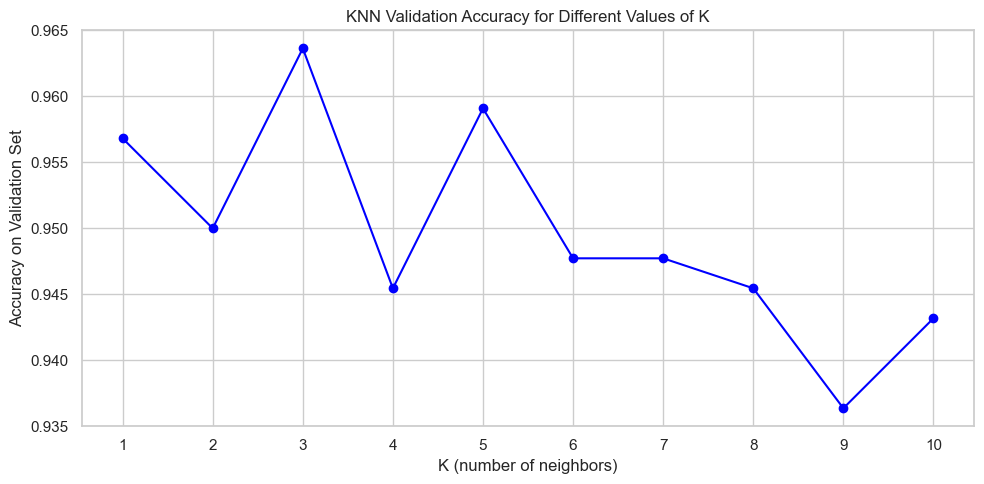

    K  Validation Accuracy
0   1             0.956818
1   2             0.950000
2   3             0.963636
3   4             0.945455
4   5             0.959091
5   6             0.947727
6   7             0.947727
7   8             0.945455
8   9             0.936364
9  10             0.943182
Best K: 3, Validation Accuracy: 0.9636


In [6]:
k_values = range(1, 11)
val_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train_scaled, y_train)
    preds = model.predict(x_val_scaled)
    val_accuracies.append(accuracy_score(y_val, preds))

plt.figure(figsize=(10, 5))
plt.plot(k_values, val_accuracies, marker="o", color="blue")
plt.title("KNN Validation Accuracy for Different Values of K")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Accuracy on Validation Set")
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

results = pd.DataFrame({
    "K": k_values,
    "Validation Accuracy": val_accuracies
})

print(results)

best_k = k_values[val_accuracies.index(max(val_accuracies))]
print(f"Best K: {best_k}, Validation Accuracy: {max(val_accuracies):.4f}")




## 4. Bias-Variance Check (Underfitting vs Overfitting)

Before locking in our chosen K, we compare training accuracy against
validation accuracy across the same range of K values. A large gap between
the two (high training accuracy, much lower validation accuracy) would signal
overfitting. Both curves being low would signal underfitting. We want our
chosen K to sit where both curves are high and close together.

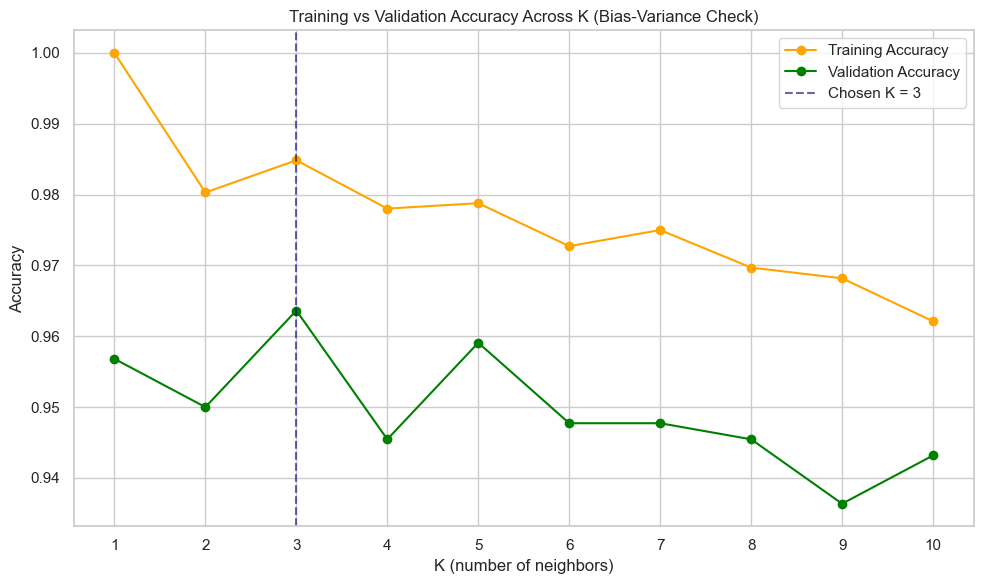

In [8]:
train_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train_scaled, y_train)
    train_accuracies.append(accuracy_score(y_train, model.predict(x_train_scaled)))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, marker="o", color="orange", label="Training Accuracy")
plt.plot(k_values, val_accuracies, marker="o", color="green", label="Validation Accuracy")
plt.axvline(best_k, color="navy", linestyle="--", alpha=0.6, label=f"Chosen K = {best_k}")

plt.title("Training vs Validation Accuracy Across K (Bias-Variance Check)")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
#Training final model with best K = 3

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(x_train_scaled, y_train)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [10]:
# Final Evaluation on Test Set

y_pred = knn_model.predict(x_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("KNN Statistics: ")

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-score: {f1:.4f}")



KNN Statistics: 
Test Accuracy: 0.9773
Test Precision: 0.9788
Test Recall: 0.9773
Test F1-score: 0.9772


In [11]:
print("Classification Report for KNN: ")
print(classification_report(y_test, y_pred))

Classification Report for KNN: 
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.91      1.00      0.95        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      0.95      0.97        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.95      0.95      0.95        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       1.00      0.85      0.92        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.95      0.97      

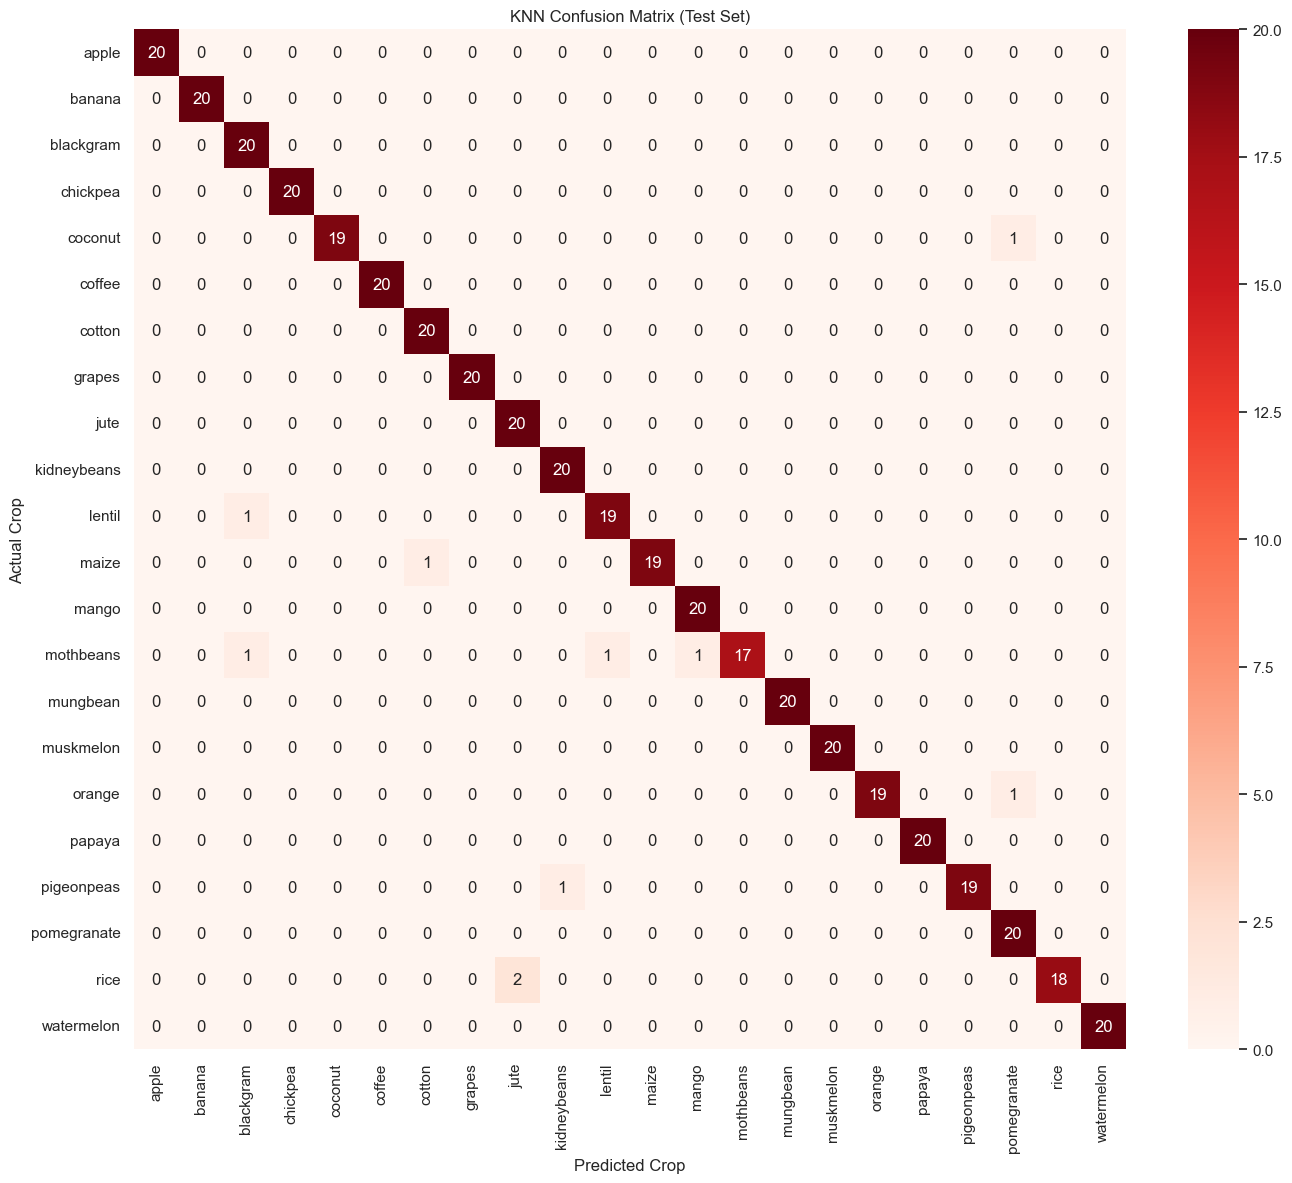

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=sorted(set(y_test)), yticklabels=sorted(set(y_test)))
plt.title("KNN Confusion Matrix (Test Set)")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
y_pred_proba = knn_model.predict_proba(x_test_scaled)
loss = log_loss(y_test, y_pred_proba)
print(f"Test Log Loss: {loss:.4f}")

Test Log Loss: 0.2078


## 7. Cross-Validation (Training Data Only)

To check that our result isn't just luck from one particular split, we run
5-fold cross-validation on the training data. This trains and tests the
model 5 separate times on different slices of the training set, giving us a
sense of how stable the model's performance really is. The test set is not
involved in this step at all.

Cross-validation scores: [0.96212121 0.97727273 0.96212121 0.97727273 0.97727273]
Mean CV accuracy: 0.9712 (+/- 0.0074)


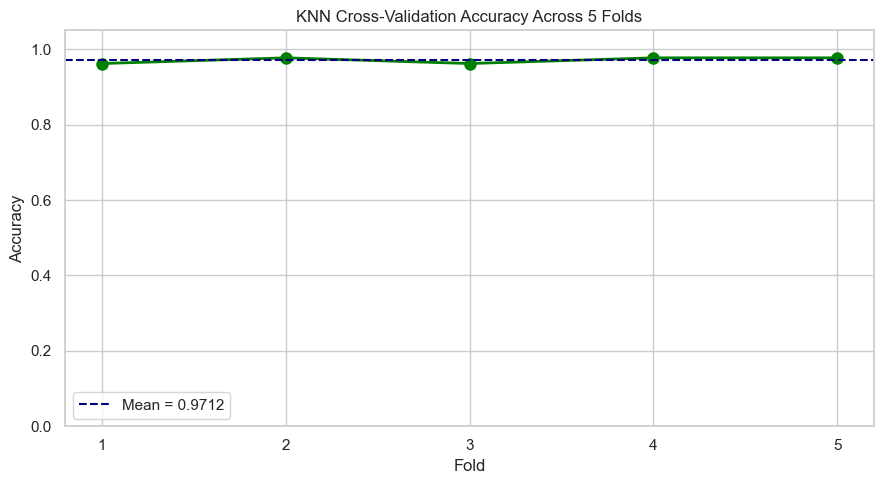

In [14]:
# cross validation for 

cv_scores = cross_val_score(knn_model, x_train_scaled, y_train, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

plt.figure(figsize=(9, 5))
folds = range(1, len(cv_scores) + 1)
plt.plot(folds, cv_scores, marker="o", color="green", linewidth=2, markersize=8)
plt.axhline(cv_scores.mean(), color="navy", linestyle="--", label=f"Mean = {cv_scores.mean():.4f}")

plt.title("KNN Cross-Validation Accuracy Across 5 Folds")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(folds)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Findings

**Choosing K:** We tested K values from 1 to 10 using the validation set. Accuracy
bounced around a fair bit rather than following a smooth curve, dropping at K=2, spiking
at K=3, dipping at K=4, spiking again at K=5, then generally declining as K increased
further, bottoming out at K=9. The best validation accuracy, 0.9636, was achieved at
K=3, so that's what we used for the final model.

**Bias-variance check:** At K=1, training accuracy was a perfect 1.00, which makes
sense, a point's single nearest neighbor is always itself, so K=1 will always memorize
the training data. This is a warning sign of overfitting. By K=3, our chosen value,
training accuracy had already dropped to about 0.985 while validation sat at 0.964, a
gap of only about 2 percentage points. Both curves generally trended downward together
as K increased further, with training accuracy staying consistently above validation
accuracy throughout, which is expected. The gap at K=3 is small enough that we're
confident this isn't a case of serious overfitting, and both scores are high enough
that it isn't underfitting either. K=3 sits in a reasonable, balanced spot.

**Final test performance:** On the untouched test set, the model scored 97.73% accuracy,
with precision at 0.9788, recall at 0.9773, and F1-score at 0.9772. These four numbers
sitting close together tells us the model performs consistently well rather than being
strong on one metric and weak on another.

**Log loss:** 0.2078. Since there are 22 possible crops, a model guessing randomly would
score around 3.09, so this low score confirms the model isn't just picking the right
crop, it's doing so with real confidence.

**Cross-validation:** Across 5 folds on the training data, scores were 0.962, 0.977,
0.962, 0.977, and 0.977, giving a mean of 0.9712 with a very small standard deviation of
0.0074. The scores stayed tightly clustered around the mean in the chart, which tells us
this performance is stable and not the result of one lucky train/test split.

**Confusion matrix:** Out of 440 test samples, KNN made 10 mistakes. The errors weren't
spread randomly, they clustered around specific crops. Mothbeans was the weakest
performer, correctly identified in only 17 of 20 cases, with the other 3 confused across
blackgram, kidneybeans, and mango. Rice had the single largest specific confusion, with
2 of 20 samples misclassified as cotton. Smaller one-off mix-ups also occurred between
lentil and blackgram, maize and cotton, coconut and watermelon, orange and pomegranate,
and pigeonpeas and kidneybeans. Some of these make agronomic sense, lentil/blackgram and
pigeonpeas/kidneybeans are legume pairs with naturally overlapping soil and nutrient
needs, so confusing them is reasonable. Others, like rice and cotton, don't share an
obvious category, suggesting these specific pairs simply have overlapping conditions in
this dataset rather than a deeper agronomic link.

KNN's main limitation is that it doesn't produce feature importance scores, so while it can
tell a farmer which crop is likely best, it can't explain which specific soil or weather
factor drove that recommendation the way Random Forest can. 